In [615]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore") # Hide warnings

sns.set_style(style= "darkgrid")
plt.rcParams["figure.figsize"] = (12, 8)

### Simple EDA

In [616]:
df = pd.read_csv("heart.csv")

In [617]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [618]:
df.columns.to_list()

['Age',
 'Sex',
 'ChestPainType',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'RestingECG',
 'MaxHR',
 'ExerciseAngina',
 'Oldpeak',
 'ST_Slope',
 'HeartDisease']

In [619]:
df.shape

(918, 12)

In [620]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [621]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [622]:
def get_numeric_features():
    numeric = df.select_dtypes(include= "number")

    return numeric

In [623]:
def get_object_features():
    obj = df.select_dtypes(include= "object")

    return obj

In [624]:
objects = get_object_features().columns
numerics = get_numeric_features().columns

print(f"Number of Object Columns : {len(objects)}")
print(f"Number of Numeric Features : {len(numerics)}")

Number of Object Columns : 5
Number of Numeric Features : 7


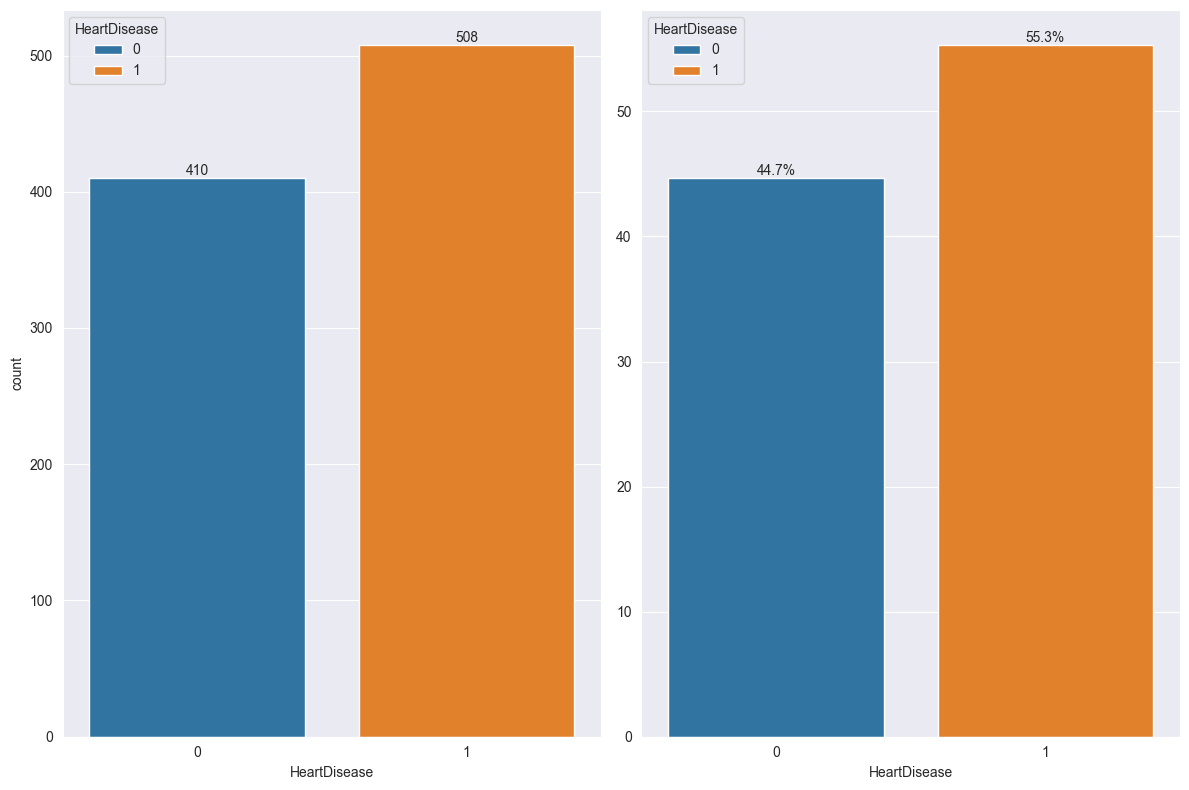

In [625]:
fig, axes = plt.subplots(1, 2)


ax0 = sns.countplot(
    data= df,
    x= "HeartDisease",
    hue= "HeartDisease",
    ax= axes[0]
)

for container in ax0.containers:
    ax0.bar_label(container)

percentages = df["HeartDisease"].value_counts(normalize= True) * 100

ax1 = sns.barplot(
    y = percentages.values,
    x = percentages.index,
    hue= percentages.index,
    ax = axes[1]
)

for container in ax1.containers:
    ax1.bar_label(container, fmt= "%.1f%%")

plt.tight_layout()
plt.show()

<Axes: >

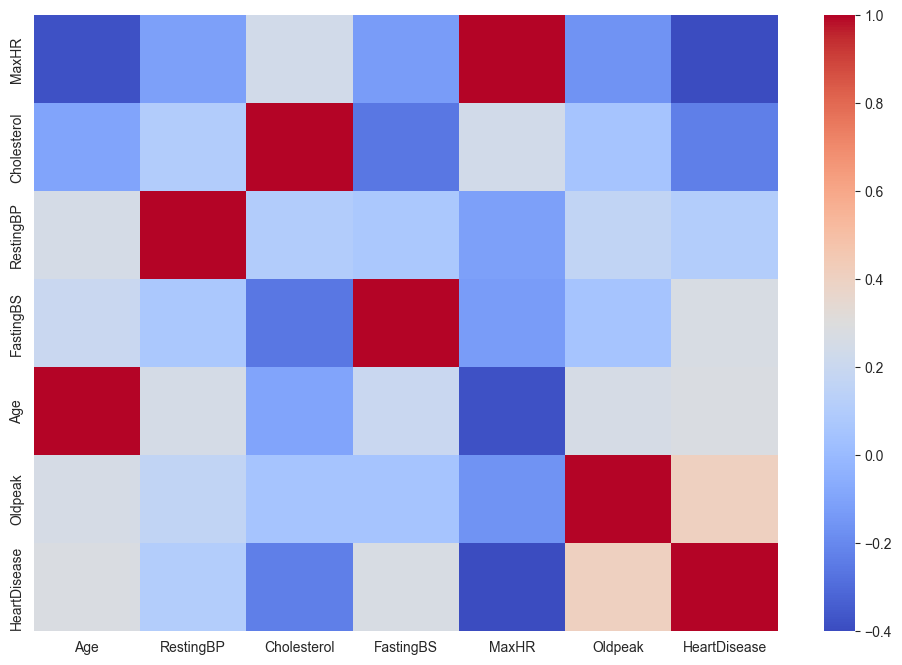

In [626]:
corr = df.corr(numeric_only= True).sort_values(by = "HeartDisease")

sns.heatmap(corr, cmap= "coolwarm")

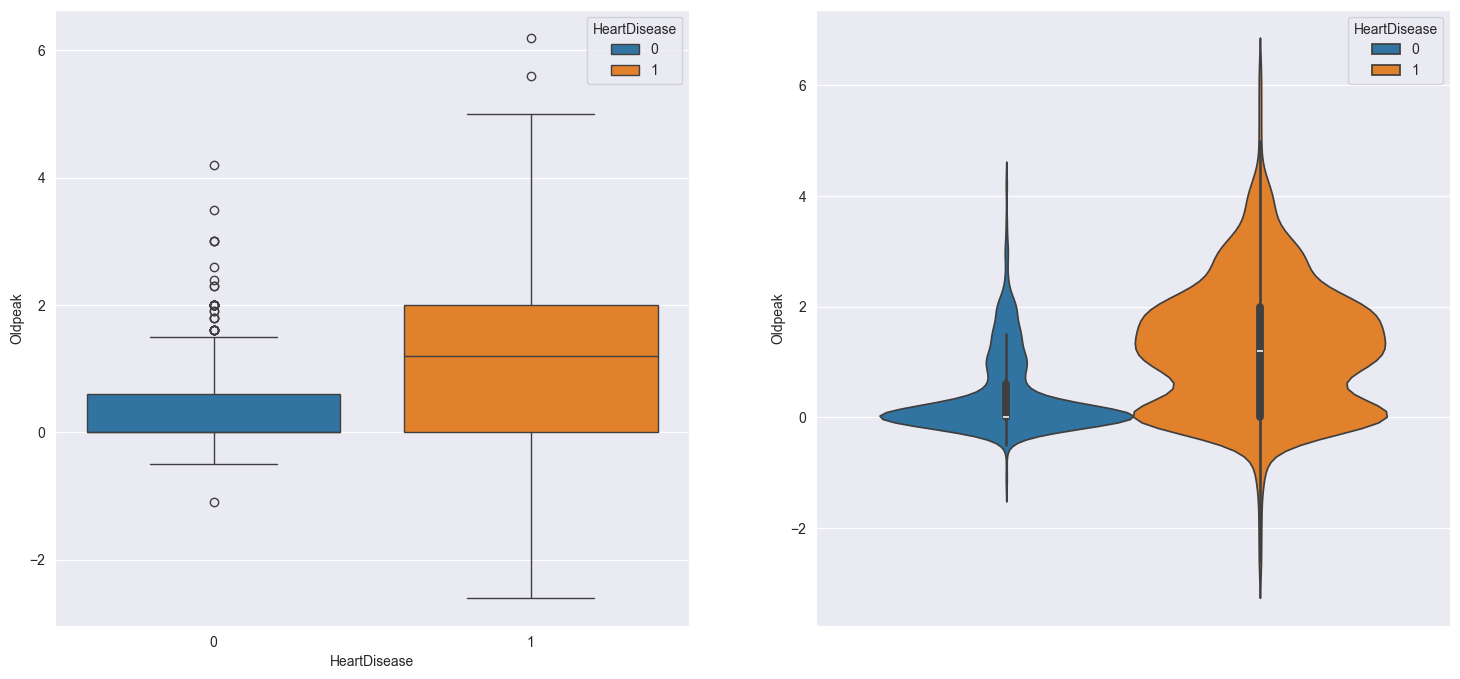

In [627]:
fig , ax = plt.subplots(1, 2, figsize = (18, 8))

sns.boxplot(
    data= df,
    y= "Oldpeak",
    x = "HeartDisease",
    hue= "HeartDisease",
    ax = ax[0]
)

sns.violinplot(
    data = df,
    y= "Oldpeak",
    hue= "HeartDisease",
    ax = ax[1]
)

plt.show()

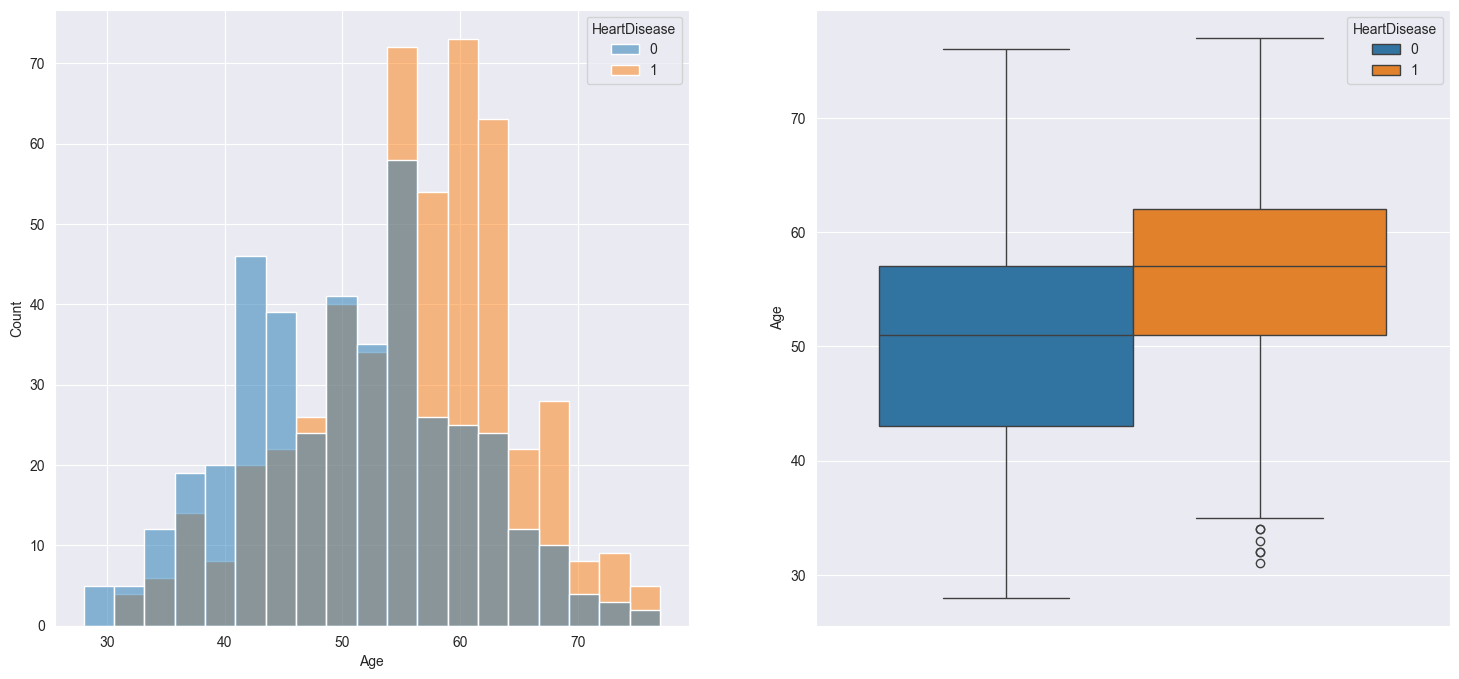

In [628]:
fig , ax = plt.subplots(1, 2, figsize = (18, 8))

sns.histplot(
    data= df,
    x= "Age",
    # y = "HeartDisease",
    hue= "HeartDisease",
    ax = ax[0]
)

sns.boxplot(
    data = df,
    y= "Age",
    hue= "HeartDisease",
    ax = ax[1]
)

plt.show()

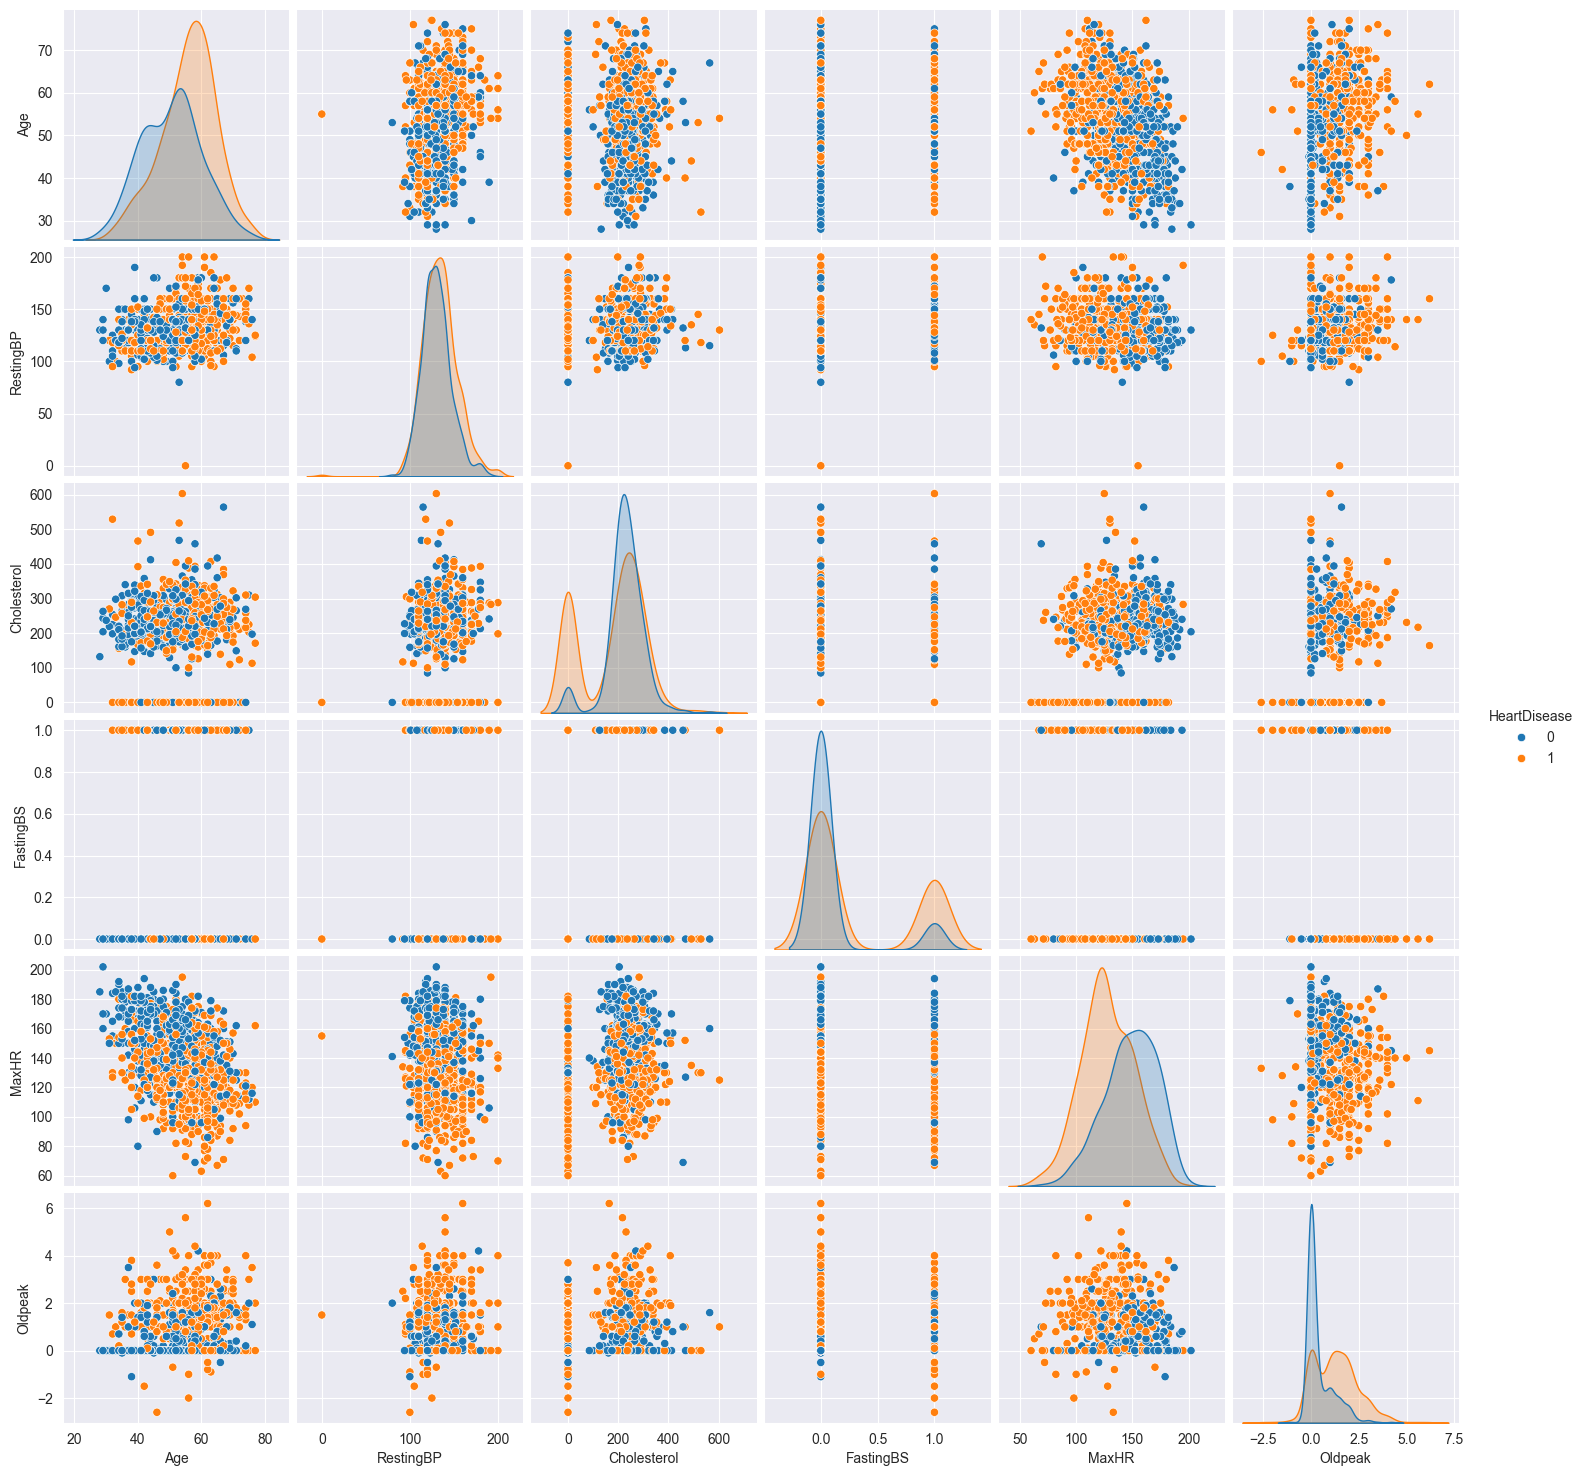

In [629]:
sns.pairplot(
    data= df,
    hue = "HeartDisease"
)

### Preprocessing

In [630]:
objects = get_object_features()
objects

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up
...,...,...,...,...,...
913,M,TA,Normal,N,Flat
914,M,ASY,Normal,N,Flat
915,M,ASY,Normal,Y,Flat
916,F,ATA,LVH,N,Flat


In [631]:
for obj in objects.columns:
    if df[obj].nunique() == 2:
        unique_vals = df[obj].unique()
        df[obj] = df[obj].map({
            unique_vals[0] : 0,
            unique_vals[1] : 1
        })
    elif df[obj].nunique() <= 10:
        df = pd.get_dummies(df, columns= [obj], drop_first= True)

In [632]:
df

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,0,140,289,0,172,0,0.0,0,True,False,False,True,False,False,True
1,49,1,160,180,0,156,0,1.0,1,False,True,False,True,False,True,False
2,37,0,130,283,0,98,0,0.0,0,True,False,False,False,True,False,True
3,48,1,138,214,0,108,1,1.5,1,False,False,False,True,False,True,False
4,54,0,150,195,0,122,0,0.0,0,False,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,110,264,0,132,0,1.2,1,False,False,True,True,False,True,False
914,68,0,144,193,1,141,0,3.4,1,False,False,False,True,False,True,False
915,57,0,130,131,0,115,1,1.2,1,False,False,False,True,False,True,False
916,57,1,130,236,0,174,0,0.0,1,True,False,False,False,False,True,False


In [633]:
X = df.drop("HeartDisease", axis = 1)
y = df["HeartDisease"]

In [634]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [635]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [636]:
scaler = StandardScaler()

In [637]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [638]:
X_train_scaled

array([[-1.24506731, -0.54060477, -0.70898547, ..., -0.48762079,
        -1.03325003, -0.84792072],
       [-1.8862362 , -0.54060477, -0.16628515, ..., -0.48762079,
        -1.03325003,  1.17935554],
       [ 0.25099346, -0.54060477,  0.91911549, ..., -0.48762079,
         0.96781995, -0.84792072],
       ...,
       [ 0.67843939, -0.54060477, -0.16628515, ..., -0.48762079,
        -1.03325003,  1.17935554],
       [ 0.67843939, -0.54060477,  1.02765555, ...,  2.05077394,
        -1.03325003,  1.17935554],
       [-1.45879027,  1.84978019,  0.91911549, ..., -0.48762079,
         0.96781995, -0.84792072]], shape=(734, 15))

In [639]:
X_test_scaled

array([[ 0.99902384,  1.84978019,  0.37641517, ..., -0.48762079,
        -1.03325003,  1.17935554],
       [-0.06959099, -0.54060477,  0.64776533, ..., -0.48762079,
         0.96781995, -0.84792072],
       [ 1.2127468 , -0.54060477,  1.46181581, ...,  2.05077394,
         0.96781995, -0.84792072],
       ...,
       [ 1.10588532, -0.54060477,  0.4306852 , ...,  2.05077394,
         0.96781995, -0.84792072],
       [-0.49703693, -0.54060477, -0.16628515, ..., -0.48762079,
        -1.03325003,  1.17935554],
       [ 1.10588532, -0.54060477,  0.5934953 , ...,  2.05077394,
         0.96781995, -0.84792072]], shape=(184, 15))

### Modeling

In [640]:
# Simple prediction
model = LogisticRegression()

In [641]:
model.fit(X_train_scaled, y_train)

LogisticRegression()

In [642]:
predicts = model.predict(X_test_scaled)

In [643]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [644]:
score = accuracy_score(y_test, predicts)
print(f"Score : {score:.2%}")
print(classification_report(y_test, predicts))
print(f"Confusion Matrix : \n{confusion_matrix(y_test, predicts)}")

Score : 85.33%
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184

Confusion Matrix : 
[[67 10]
 [17 90]]


In [645]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

In [646]:
# Prediction with Hyperparameters with
model = LogisticRegression()
cv = StratifiedKFold()

In [647]:
penalty = ["l1", "l2", "elasticnet"]
C_values = [100, 10, 0.1, 0.01]
solver = ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"]
class_weight = [{0 : w , 1 : y} for w in [0.1, 1, 10 ,100] for y in [0.1, 1, 10 ,100]]

In [648]:
params = dict(
    penalty = penalty,
    C = C_values,
    solver = solver,
    class_weight = class_weight)

In [649]:
params

{'penalty': ['l1', 'l2', 'elasticnet'],
 'C': [100, 10, 0.1, 0.01],
 'solver': ['lbfgs',
  'liblinear',
  'newton-cg',
  'newton-cholesky',
  'sag',
  'saga'],
 'class_weight': [{0: 0.1, 1: 0.1},
  {0: 0.1, 1: 1},
  {0: 0.1, 1: 10},
  {0: 0.1, 1: 100},
  {0: 1, 1: 0.1},
  {0: 1, 1: 1},
  {0: 1, 1: 10},
  {0: 1, 1: 100},
  {0: 10, 1: 0.1},
  {0: 10, 1: 1},
  {0: 10, 1: 10},
  {0: 10, 1: 100},
  {0: 100, 1: 0.1},
  {0: 100, 1: 1},
  {0: 100, 1: 10},
  {0: 100, 1: 100}]}

In [650]:
grid = GridSearchCV(
    estimator= model,
    param_grid= params,
    cv= cv,
    scoring= "accuracy",
    n_jobs= -1
)

In [651]:
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [100, 10, 0.1, 0.01],
                         'class_weight': [{0: 0.1, 1: 0.1}, {0: 0.1, 1: 1},
                                          {0: 0.1, 1: 10}, {0: 0.1, 1: 100},
                                          {0: 1, 1: 0.1}, {0: 1, 1: 1},
                                          {0: 1, 1: 10}, {0: 1, 1: 100},
                                          {0: 10, 1: 0.1}, {0: 10, 1: 1},
                                          {0: 10, 1: 10}, {0: 10, 1: 100},
                                          {0: 100, 1: 0.1}, {0: 100, 1: 1},
                                          {0: 100, 1: 10}, {0: 100, 1: 100}],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cholesky', 'sag', 'saga']},
             scoring='accuracy')

In [652]:
grid.best_params_

{'C': 0.1, 'class_weight': {0: 1, 1: 1}, 'penalty': 'l2', 'solver': 'lbfgs'}

In [653]:
predicts = grid.predict(X_test_scaled)

In [654]:
score = accuracy_score(y_test, predicts)
print(f"Score : {score:.2%}")
print(classification_report(y_test, predicts))
print(f"Confusion Matrix\n : {confusion_matrix(y_test, predicts)}")

Score : 85.33%
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184

Confusion Matrix
 : [[67 10]
 [17 90]]


In [655]:
# Analysing the metrics with class weights
model = LogisticRegression()

In [656]:
# The model performs the best accuracy with equal weights because the target is balanced
class_weights = [
 {0: 0.1, 1: 0.1},
 {0: 0.1, 1: 1},
 {0: 0.1, 1: 10},
 {0: 0.1, 1: 100},
 {0: 1, 1: 0.1},
 {0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 100},
 {0: 10, 1: 0.1},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 100},
 {0: 100, 1: 0.1},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 100}]

for weight in class_weights:
    model = LogisticRegression(class_weight= weight)

    model.fit(X_train_scaled, y_train)
    predicts = model.predict(X_test_scaled)

    score = accuracy_score(y_test, predicts)
    print(f"Score : {score:.2%}")
    print("class_weight:", weight)
    print(confusion_matrix(y_test, predicts))
    print("-"*40)

Score : 85.33%
class_weight: {0: 0.1, 1: 0.1}
[[67 10]
 [17 90]]
----------------------------------------
Score : 81.52%
class_weight: {0: 0.1, 1: 1}
[[ 46  31]
 [  3 104]]
----------------------------------------
Score : 65.22%
class_weight: {0: 0.1, 1: 10}
[[ 13  64]
 [  0 107]]
----------------------------------------
Score : 60.87%
class_weight: {0: 0.1, 1: 100}
[[  5  72]
 [  0 107]]
----------------------------------------
Score : 60.33%
class_weight: {0: 1, 1: 0.1}
[[76  1]
 [72 35]]
----------------------------------------
Score : 85.33%
class_weight: {0: 1, 1: 1}
[[67 10]
 [17 90]]
----------------------------------------
Score : 81.52%
class_weight: {0: 1, 1: 10}
[[ 46  31]
 [  3 104]]
----------------------------------------
Score : 67.39%
class_weight: {0: 1, 1: 100}
[[ 17  60]
 [  0 107]]
----------------------------------------
Score : 46.20%
class_weight: {0: 10, 1: 0.1}
[[77  0]
 [99  8]]
----------------------------------------
Score : 61.41%
class_weight: {0: 10, 1: 1